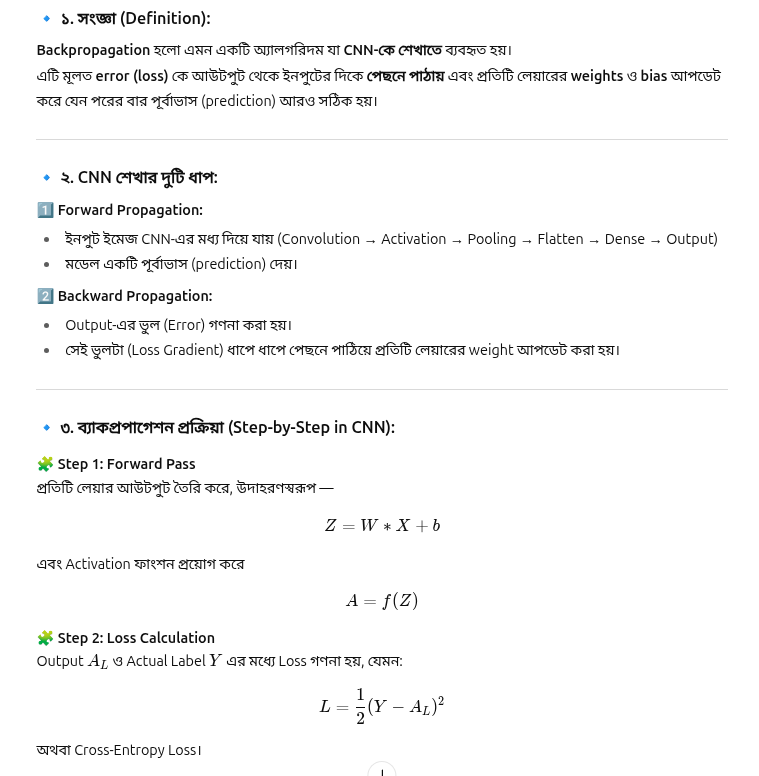

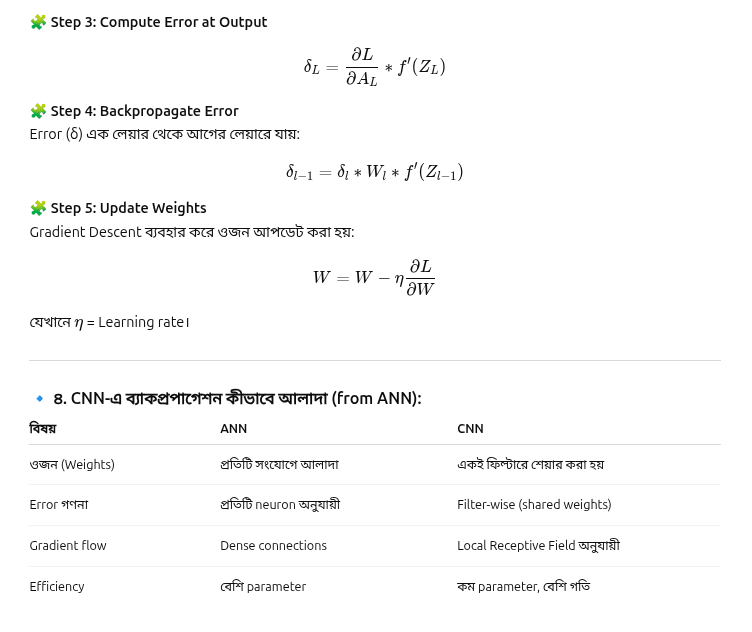

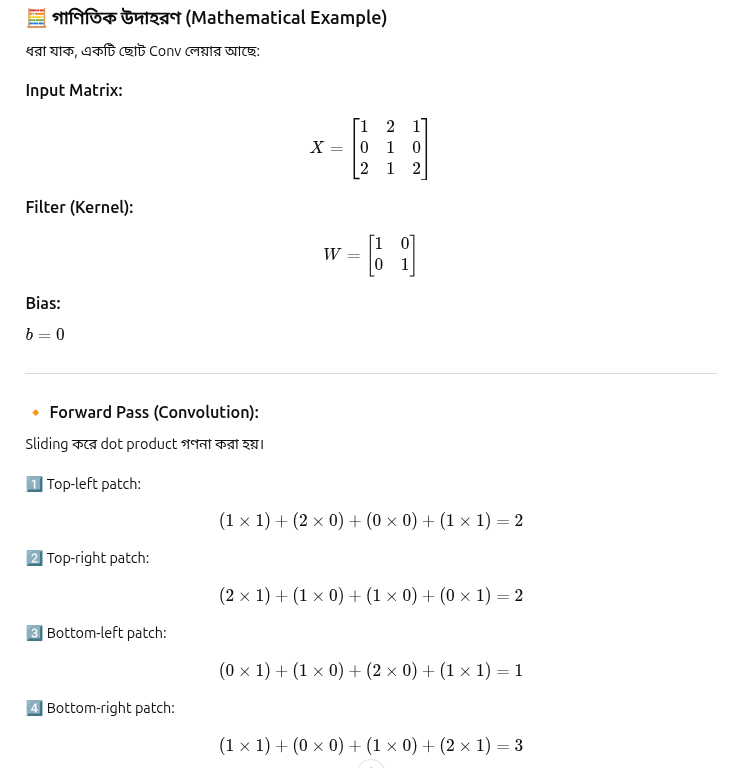

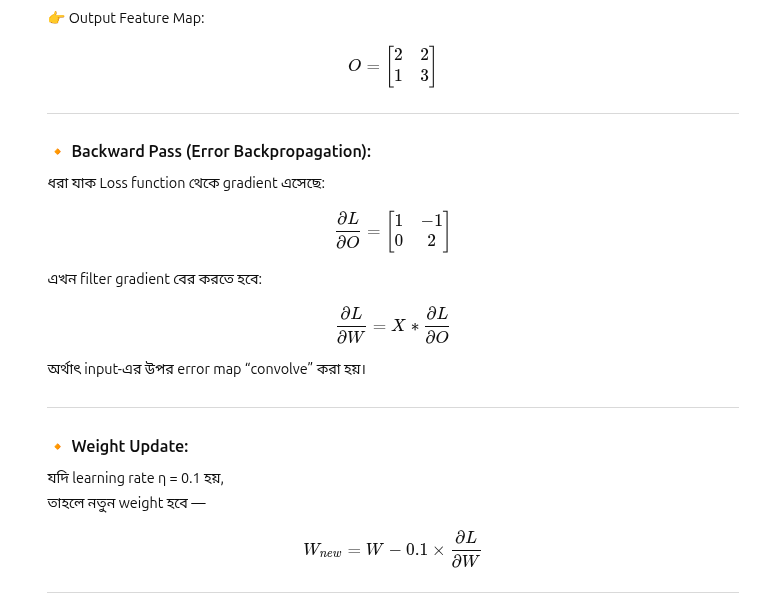

**Example 1: Simple CNN with Backpropagation**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# মডেল তৈরি
model = models.Sequential([
    layers.Conv2D(2, (2,2), activation='relu', input_shape=(3,3,1)),  # 2টি ফিল্টার
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
])

# কম্পাইল (loss + optimizer)
model.compile(optimizer='sgd', loss='binary_crossentropy')

# ইনপুট ডেটা (একটি 3x3 ইমেজ)
X = tf.constant([[[[1.0],[2.0],[1.0]],
                  [[0.0],[1.0],[0.0]],
                  [[2.0],[1.0],[2.0]]]])

# টার্গেট লেবেল
Y = tf.constant([[1.0]])

# মডেল ট্রেন করা (একটি ধাপে)
model.fit(X, Y, epochs=1, verbose=1)

2025-10-22 00:08:38.557424: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-22 00:08:38.558345: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-22 00:08:38.565260: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-22 00:08:38.586622: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761070118.620079   16523 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761070118.62

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step - loss: 0.6610


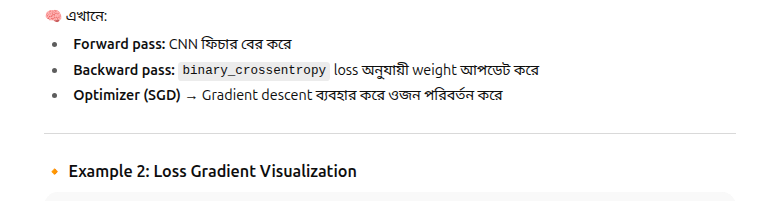

In [2]:
# Gradient Tape ব্যবহার করে Backpropagation দেখা
with tf.GradientTape() as tape:
    y_pred = model(X)
    loss = tf.keras.losses.binary_crossentropy(Y, y_pred)

grads = tape.gradient(loss, model.trainable_variables)
for g in grads:
    print(g.numpy())  # প্রতিটি লেয়ারের gradient দেখা

[[[[ 0.          0.        ]]

  [[-0.20399281  0.        ]]]


 [[[-0.40798563  0.        ]]

  [[-0.20399281  0.        ]]]]
[-0.20399281  0.        ]
[[ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.08121773]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]]
[-0.48088938]


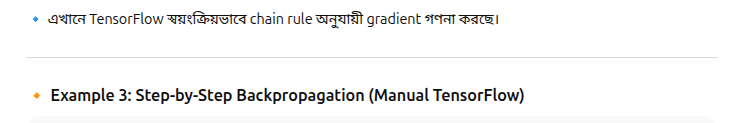

In [3]:
import tensorflow as tf

# ডেটা ও ওজন নির্ধারণ
x = tf.constant([[1.0, 2.0]])
W = tf.Variable([[0.5], [0.3]])
b = tf.Variable([0.1])

# ব্যাকপ্রপাগেশন টেপ
with tf.GradientTape() as tape:
    z = tf.matmul(x, W) + b  # Forward pass
    y = tf.sigmoid(z)
    loss = (1 - y)**2        # Simple loss

# Gradient গণনা
dW, db = tape.gradient(loss, [W, b])
print("Gradient dW:", dW.numpy())
print("Gradient db:", db.numpy())

Gradient dW: [[-0.08235632]
 [-0.16471264]]
Gradient db: [-0.08235632]


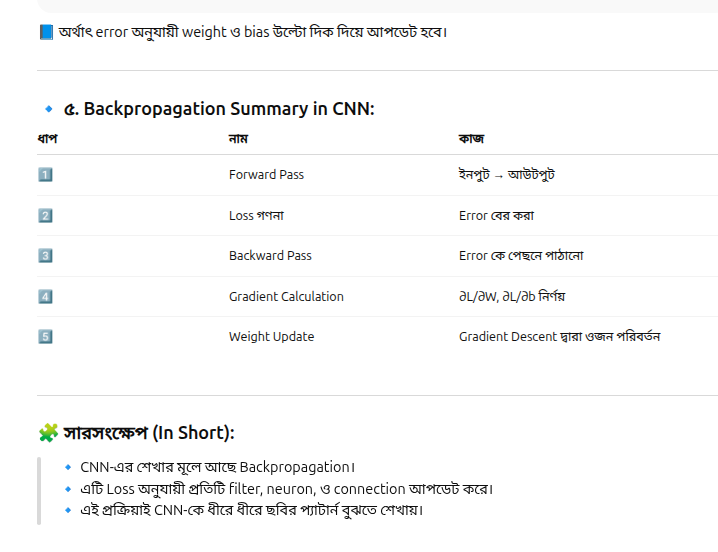

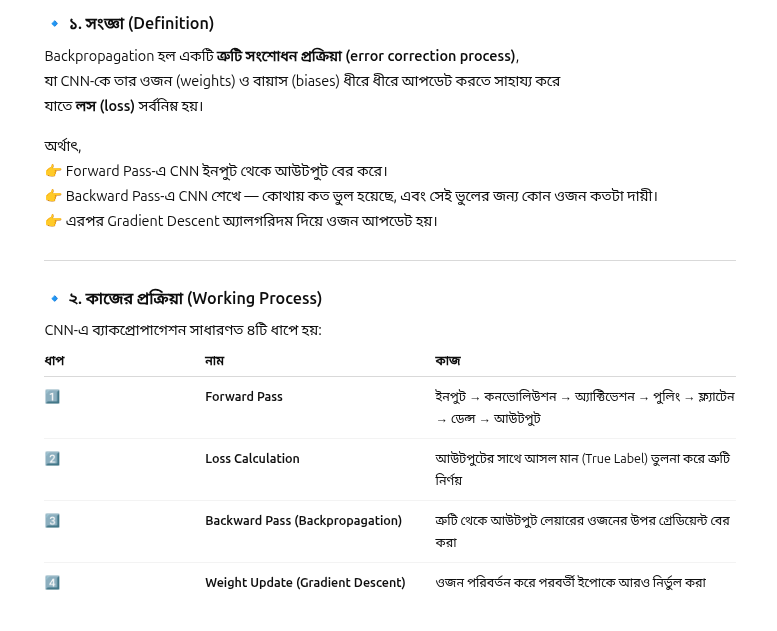

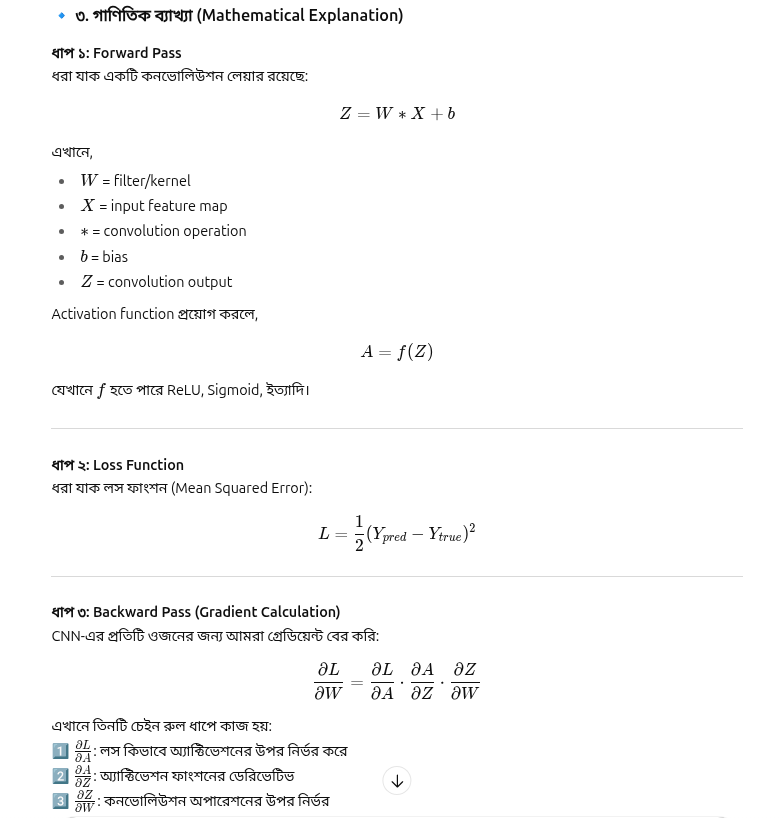

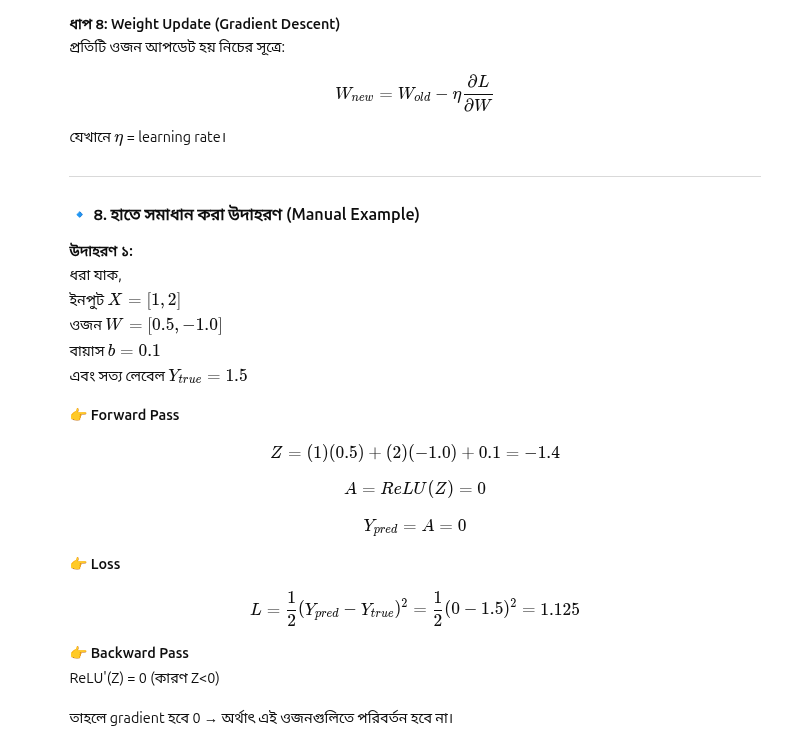

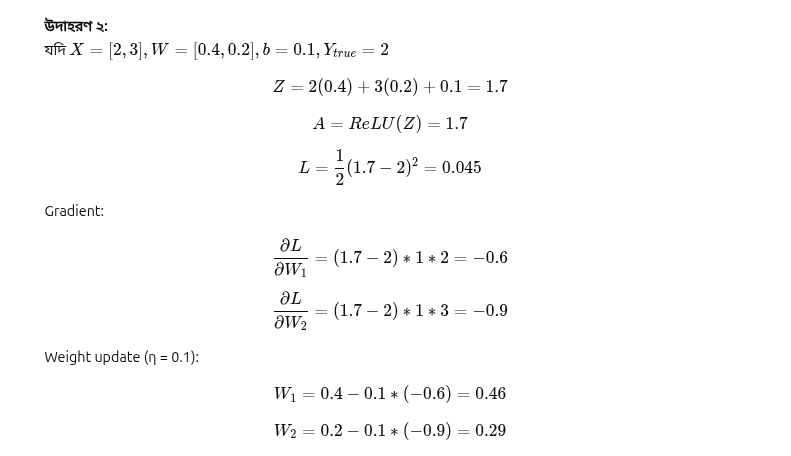

In [4]:
# 🧠 ব্যাকপ্রোপাগেশন সহ একটি সরল CNN মডেল
import tensorflow as tf
from tensorflow.keras import layers, models

# ✅ মডেল তৈরি
model = models.Sequential([
    layers.Conv2D(8, (3,3), activation='relu', input_shape=(28,28,1)),  # কনভোলিউশন লেয়ার
    layers.MaxPooling2D((2,2)),  # পুলিং লেয়ার
    layers.Flatten(),             # ফ্ল্যাটেন লেয়ার
    layers.Dense(10, activation='softmax')  # আউটপুট লেয়ার
])

# ✅ মডেল কম্পাইল (লস, অপ্টিমাইজার, মেট্রিক নির্ধারণ)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ✅ ট্রেনিং (Backpropagation এখানে স্বয়ংক্রিয়ভাবে হয়)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()  # MNIST ডেটা
x_train = x_train.reshape((-1, 28, 28, 1)) / 255.0
x_test = x_test.reshape((-1, 28, 28, 1)) / 255.0

# ✅ মডেল প্রশিক্ষণ (এখানে backpropagation স্বয়ংক্রিয়)
model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9082 - loss: 0.3237 - val_accuracy: 0.9554 - val_loss: 0.1641
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9597 - loss: 0.1422 - val_accuracy: 0.9675 - val_loss: 0.1110
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9710 - loss: 0.1019 - val_accuracy: 0.9724 - val_loss: 0.0933


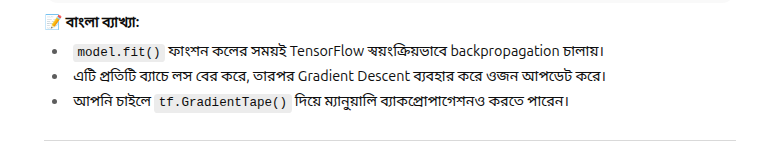